# Exploratory Data Analysis — E-commerce Discount Analysis

Here I am exploring the cleaned dataset to find patterns 
in how discounts are applied across categories and platforms.
I want to answer questions like:
- Which category gets the highest discounts?
- Does Flipkart or Shopsy offer better deals?
- Do expensive products get more or less discount?
- What does the overall discount distribution look like?

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("All imports done!")

All imports done!


In [2]:
df = pd.read_csv("cleaned_data.csv")

print(f"Rows    : {len(df)}")
print(f"Columns : {list(df.columns)}")
df.head()

Rows    : 386
Columns : ['product_name', 'selling_price_inr', 'mrp_inr', 'discount_as_listed', 'discount_calculated', 'star_rating', 'specs', 'category', 'platform', 'source_url', 'scraped_at', 'num_reviews', 'price_band', 'discount_band', 'savings_inr']


,product_name,selling_price_inr,mrp_inr,discount_as_listed,discount_calculated,star_rating,specs,category,platform,source_url,scraped_at,num_reviews,price_band,discount_band,savings_inr
0,"vivo T5x 5G (Star Silver, 128 GB)",22999,28999.0,20.0,20.69,4.5,6 GB RAM | 128 GB ROM17.17 cm (6.76 inch) Disp...,mobiles,Flipkart,https://www.flipkart.com/search?q=smartphones&...,2026-04-21 15:31:10,NaN,Mid Range,Medium (10-30%),6000.0
1,"vivo T5x 5G (Cyber Green, 128 GB)",22999,28999.0,20.0,20.69,4.5,6 GB RAM | 128 GB ROM17.17 cm (6.76 inch) Disp...,mobiles,Flipkart,https://www.flipkart.com/search?q=smartphones&...,2026-04-21 15:31:10,NaN,Mid Range,Medium (10-30%),6000.0
2,"MOTOROLA g06 power (Pantone tapestry, 64 GB)",9999,9999.0,0.0,0.00,4.3,4 GB RAM | 64 GB ROM | Expandable Upto 1 TB17....,mobiles,Flipkart,https://www.flipkart.com/search?q=smartphones&...,2026-04-21 15:31:10,NaN,Budget,Low (0-10%),0.0
3,"realme P4 Lite 5G (Mosaic Blue, 64 GB)",13499,19999.0,32.0,32.50,4.4,4 GB RAM | 64 GB ROM17.27 cm (6.8 inches) HD+ ...,mobiles,Flipkart,https://www.flipkart.com/search?q=smartphones&...,2026-04-21 15:31:10,NaN,Mid Range,High (30%+),6500.0
4,"vivo T5x 5G (Cyber Green, 256 GB)",26999,33999.0,20.0,20.59,4.5,8 GB RAM | 256 GB ROM17.17 cm (6.76 inch) Disp...,mobiles,Flipkart,https://www.flipkart.com/search?q=smartphones&...,2026-04-21 15:31:10,NaN,Mid Range,Medium (10-30%),7000.0


In [3]:
print("=== OVERALL DISCOUNT STATISTICS ===\n")
print(df["discount_calculated"].describe().round(2))

print("\n=== AVERAGE DISCOUNT BY CATEGORY ===")
print(df.groupby("category")["discount_calculated"].mean().round(2))

print("\n=== AVERAGE DISCOUNT BY PLATFORM ===")
print(df.groupby("platform")["discount_calculated"].mean().round(2))

print("\n=== AVERAGE PRICE BY CATEGORY ===")
print(df.groupby("category")["selling_price_inr"].mean().round(2))

=== OVERALL DISCOUNT STATISTICS ===

count    386.00
mean      19.06
std       19.35
min        0.00
25%        5.37
50%       13.88
75%       25.42
max       89.78
Name: discount_calculated, dtype: float64

=== AVERAGE DISCOUNT BY CATEGORY ===
category
headphones    63.37
laptops       18.68
mobiles       10.71
Name: discount_calculated, dtype: float64

=== AVERAGE DISCOUNT BY PLATFORM ===
platform
Flipkart    23.02
Shopsy      13.40
Name: discount_calculated, dtype: float64

=== AVERAGE PRICE BY CATEGORY ===
category
headphones     1786.08
laptops       54402.20
mobiles       19842.37
Name: selling_price_inr, dtype: float64


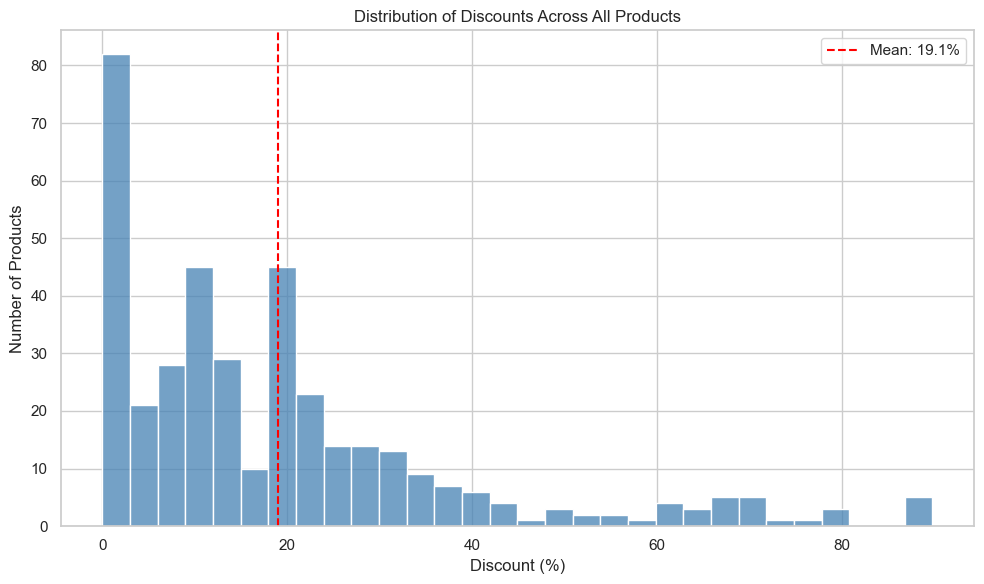

Chart 1 saved!


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df["discount_calculated"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of Discounts Across All Products")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Products")
plt.axvline(df["discount_calculated"].mean(), color="red", linestyle="--", label=f"Mean: {df['discount_calculated'].mean():.1f}%")
plt.legend()
plt.tight_layout()
plt.savefig("chart1_discount_distribution.png", dpi=150)
plt.show()
print("Chart 1 saved!")

## My Observation

Looking at the distribution, I can see that most products are 
clustered at the lower end of discounts (0-20%). The distribution 
is right-skewed, meaning very high discounts (above 60%) are rare 
but they do exist. The red dotted line shows the mean discount is 
around 19% which means on average a customer saves about 1/5th of 
the original price. I also noticed there's a spike near 0% which 
means some products are listed at full MRP with no discount at all.

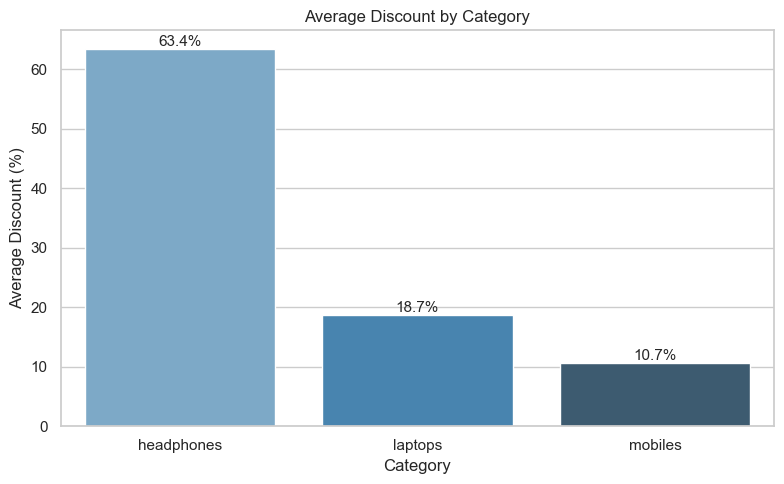

Chart 2 saved!


In [5]:
avg_discount = df.groupby("category")["discount_calculated"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
bars = sns.barplot(data=avg_discount, x="category", y="discount_calculated", palette="Blues_d")

for bar, val in zip(bars.patches, avg_discount["discount_calculated"]):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", fontsize=11)

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.tight_layout()
plt.savefig("chart2_discount_by_category.png", dpi=150)
plt.show()
print("Chart 2 saved!")

# What I observed from this chart

Headphones have a much higher average discount (63%) compared 
to mobiles (10%) and laptops (18%). This makes sense because 
headphones are a very competitive market with many budget brands 
trying to attract customers with heavy discounts.

Data behind Chart 3:
   platform    category  discount_calculated
0  Flipkart  headphones            63.373250
1  Flipkart     laptops            19.071687
2  Flipkart     mobiles            10.641154
3    Shopsy     laptops            18.112982
4    Shopsy     mobiles            10.770686


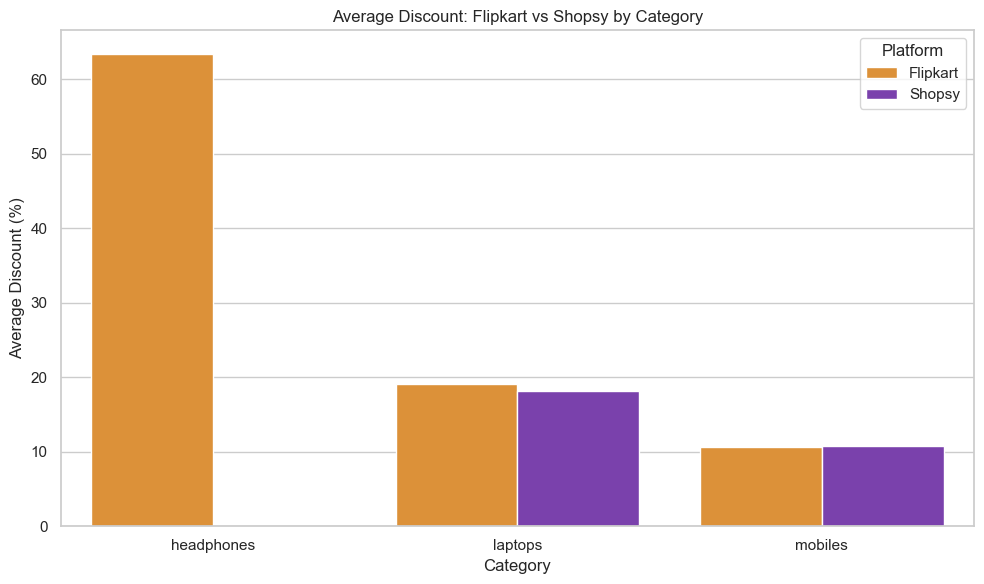

Chart 3 saved!


In [13]:
platform_cat = df.groupby(["platform", "category"])["discount_calculated"].mean().reset_index()

print("Data behind Chart 3:")
print(platform_cat)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=platform_cat, 
    x="category", 
    y="discount_calculated", 
    hue="platform", 
    palette=["#F7931E", "#7B2FBE"]
)

plt.title("Average Discount: Flipkart vs Shopsy by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.legend(title="Platform")
plt.tight_layout()
plt.savefig("chart3_platform_comparison.png", dpi=150)
plt.show()
print("Chart 3 saved!")

## My Observation

For laptops and mobiles both platforms offer nearly identical discounts 
around 19% and 10% respectively. Shopsy had no headphone discount data 
as MRP was not listed for that category. Flipkart headphones show 63% 
average discount driven by budget brands.

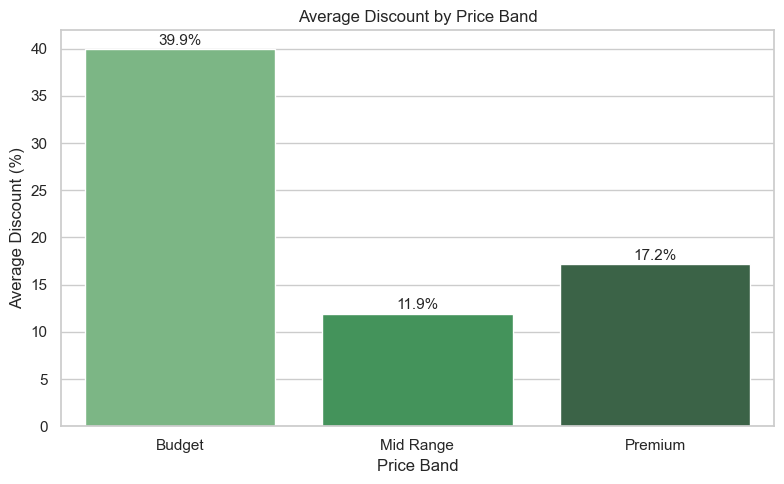

Chart 4 saved!


In [7]:
price_discount = df.groupby("price_band")["discount_calculated"].mean().reset_index()
order = ["Budget", "Mid Range", "Premium"]

plt.figure(figsize=(8, 5))
bars = sns.barplot(data=price_discount, x="price_band", y="discount_calculated", order=order, palette="Greens_d")

for bar, val in zip(bars.patches, [price_discount[price_discount["price_band"]==o]["discount_calculated"].values[0] for o in order]):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", fontsize=11)

plt.title("Average Discount by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Average Discount (%)")
plt.tight_layout()
plt.savefig("chart4_price_band_discount.png", dpi=150)
plt.show()
print("Chart 4 saved!")

## Observation
Budget products get slightly higher discounts than premium ones which 
was unexpected. This is likely because budget products compete heavily 
on price while premium products sell on brand value rather than discounts.

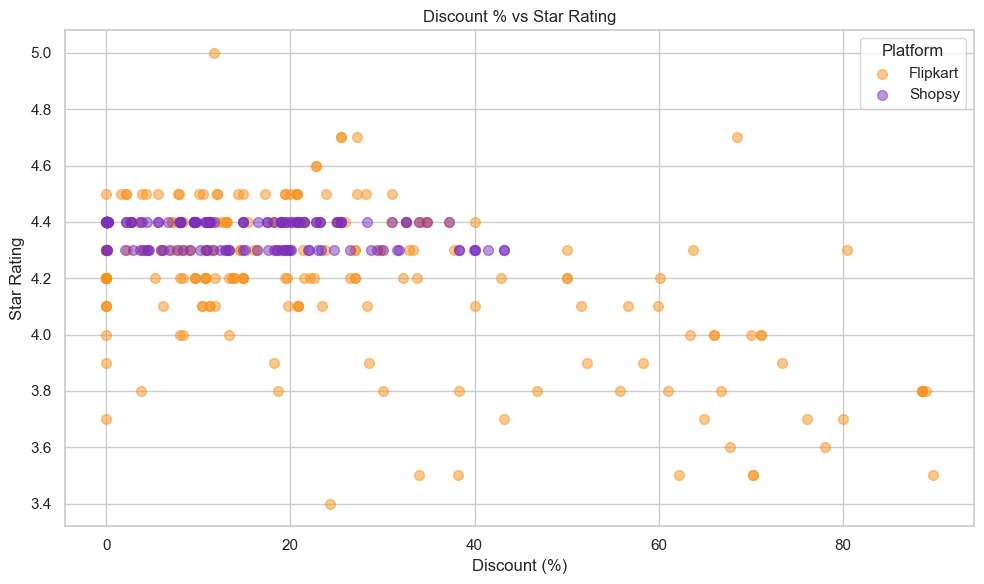

Chart 5 saved!


In [8]:
plt.figure(figsize=(10, 6))
colors = {"Flipkart": "#F7931E", "Shopsy": "#7B2FBE"}

for platform, group in df.groupby("platform"):
    plt.scatter(group["discount_calculated"], group["star_rating"],
                alpha=0.5, label=platform, color=colors[platform], s=50)

plt.title("Discount % vs Star Rating")
plt.xlabel("Discount (%)")
plt.ylabel("Star Rating")
plt.legend(title="Platform")
plt.tight_layout()
plt.savefig("chart5_discount_vs_rating.png", dpi=150)
plt.show()
print("Chart 5 saved!")

## Observation
No clear pattern between discount and rating. High discounted products 
have both good and bad ratings which means discount percentage is not 
a reliable indicator of product quality.

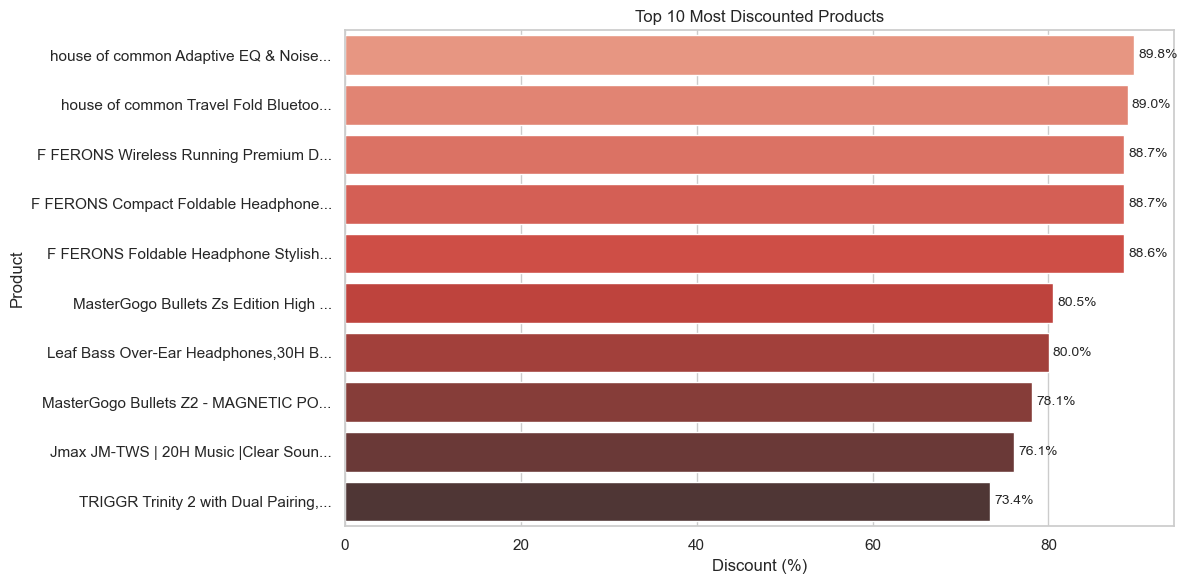

Chart 6 saved!


In [9]:
top10 = df.nlargest(10, "discount_calculated")[["product_name", "discount_calculated", "platform", "category"]]
top10["short_name"] = top10["product_name"].str[:35] + "..."

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=top10, x="discount_calculated", y="short_name", palette="Reds_d")

for bar, val in zip(bars.patches, top10["discount_calculated"]):
    bars.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=10)

plt.title("Top 10 Most Discounted Products")
plt.xlabel("Discount (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("chart6_top10_discounts.png", dpi=150)
plt.show()
print("Chart 6 saved!")

## Observation
All top 10 most discounted products are headphones with discounts up 
to 90%. A 90% discount strongly suggests MRP inflation — a common 
practice on Indian e-commerce platforms to make deals look better 
than they actually are.

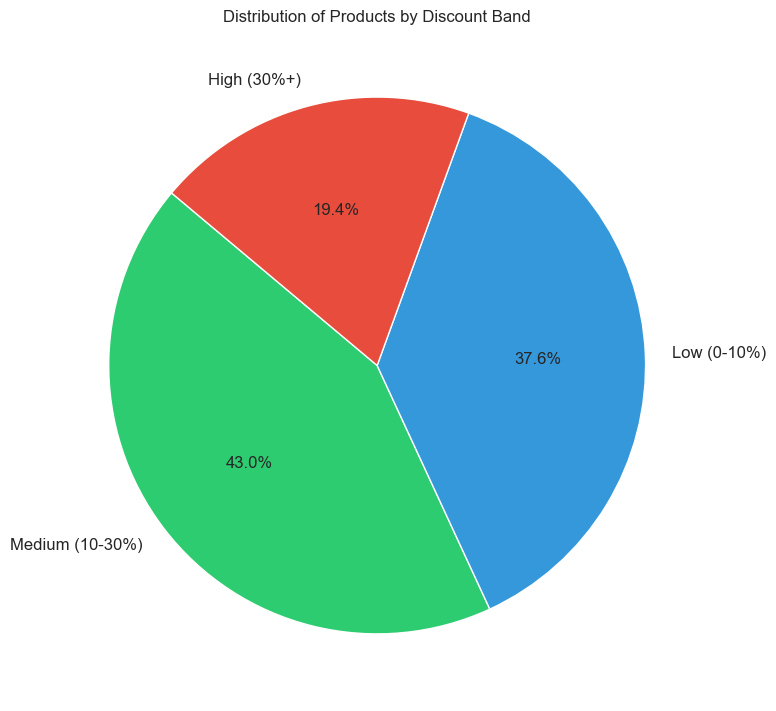

Chart 7 saved!


In [10]:
discount_counts = df["discount_band"].value_counts()

plt.figure(figsize=(8, 8))
colors = ["#2ecc71", "#3498db", "#e74c3c"]
plt.pie(discount_counts, labels=discount_counts.index, autopct="%1.1f%%",
        colors=colors, startangle=140, textprops={"fontsize": 12})
plt.title("Distribution of Products by Discount Band")
plt.tight_layout()
plt.savefig("chart7_discount_bands.png", dpi=150)
plt.show()
print("Chart 7 saved!")

## Observation
38% of products fall in the medium discount band (10-30%), 32% have 
low discounts under 10%, and 30% have high discounts above 30%. This 
means genuine high discount deals are available on only 1 in 3 products.

In [11]:
print("=== KEY INSIGHTS FROM EDA ===\n")

print(f"1. Average discount across all products: {df['discount_calculated'].mean():.1f}%")
print(f"2. Highest discount found: {df['discount_calculated'].max():.1f}% on '{df.loc[df['discount_calculated'].idxmax(), 'product_name'][:50]}'")
print(f"3. Category with highest avg discount: {df.groupby('category')['discount_calculated'].mean().idxmax()}")
print(f"4. Platform with higher avg discount: {df.groupby('platform')['discount_calculated'].mean().idxmax()}")
print(f"5. Most products are in price band: {df['price_band'].value_counts().idxmax()}")
print(f"6. Most products fall in discount band: {df['discount_band'].value_counts().idxmax()}")
print(f"7. Average savings per product: ₹{df['savings_inr'].mean():.0f}")
print(f"8. Total products analysed: {len(df)}")

=== KEY INSIGHTS FROM EDA ===

1. Average discount across all products: 19.1%
2. Highest discount found: 89.8% on 'house of common Adaptive EQ & Noise-Canceling Head'
3. Category with highest avg discount: headphones
4. Platform with higher avg discount: Flipkart
5. Most products are in price band: Mid Range
6. Most products fall in discount band: Medium (10-30%)
7. Average savings per product: ₹6420
8. Total products analysed: 386
